### SENTIMENT DATASET ANALYSIS

In [1]:
#libraries
import pandas as pd
import matplotlib.pyplot as plt

### DATASET

In [2]:
df = pd.read_csv('Sentiment.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [3]:
#shape of the dataset
df.shape

(732, 15)

##### - The dataset contains 732 rows and 15 columns.

In [4]:
#column names
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='object')

In [5]:
#data types
df.dtypes

Unnamed: 0.1      int64
Unnamed: 0        int64
Text             object
Sentiment        object
Timestamp        object
User             object
Platform         object
Hashtags         object
Retweets        float64
Likes           float64
Country          object
Year              int64
Month             int64
Day               int64
Hour              int64
dtype: object

In [6]:
#missing values
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

### DATA CLEANING

In [7]:
#remove unnecessary columns
df = df.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1)

In [8]:
#shape of the dataset
df.shape

(732, 13)

In [9]:
#convert time stamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [10]:
#remove extra spaces in the column names
df.columns = df.columns.str.strip()

In [11]:
#clean text_columns
text_columns = ['Sentiment', 'Platform', 'Country']

for col in text_columns:
    df[col] = df[col].str.strip().str.lower()

In [13]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,positive,2023-01-15 12:30:00,User123,twitter,#Nature #Park,15.0,30.0,usa,2023,1,15,12
1,Traffic was terrible this morning. ...,negative,2023-01-15 08:45:00,CommuterX,twitter,#Traffic #Morning,5.0,10.0,canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,positive,2023-01-15 15:45:00,FitnessFan,instagram,#Fitness #Workout,20.0,40.0,usa,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,positive,2023-01-15 18:20:00,AdventureX,facebook,#Travel #Adventure,8.0,15.0,uk,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,neutral,2023-01-15 19:55:00,ChefCook,instagram,#Cooking #Food,12.0,25.0,australia,2023,1,15,19


### SENTIMENT DISTRIBUTION

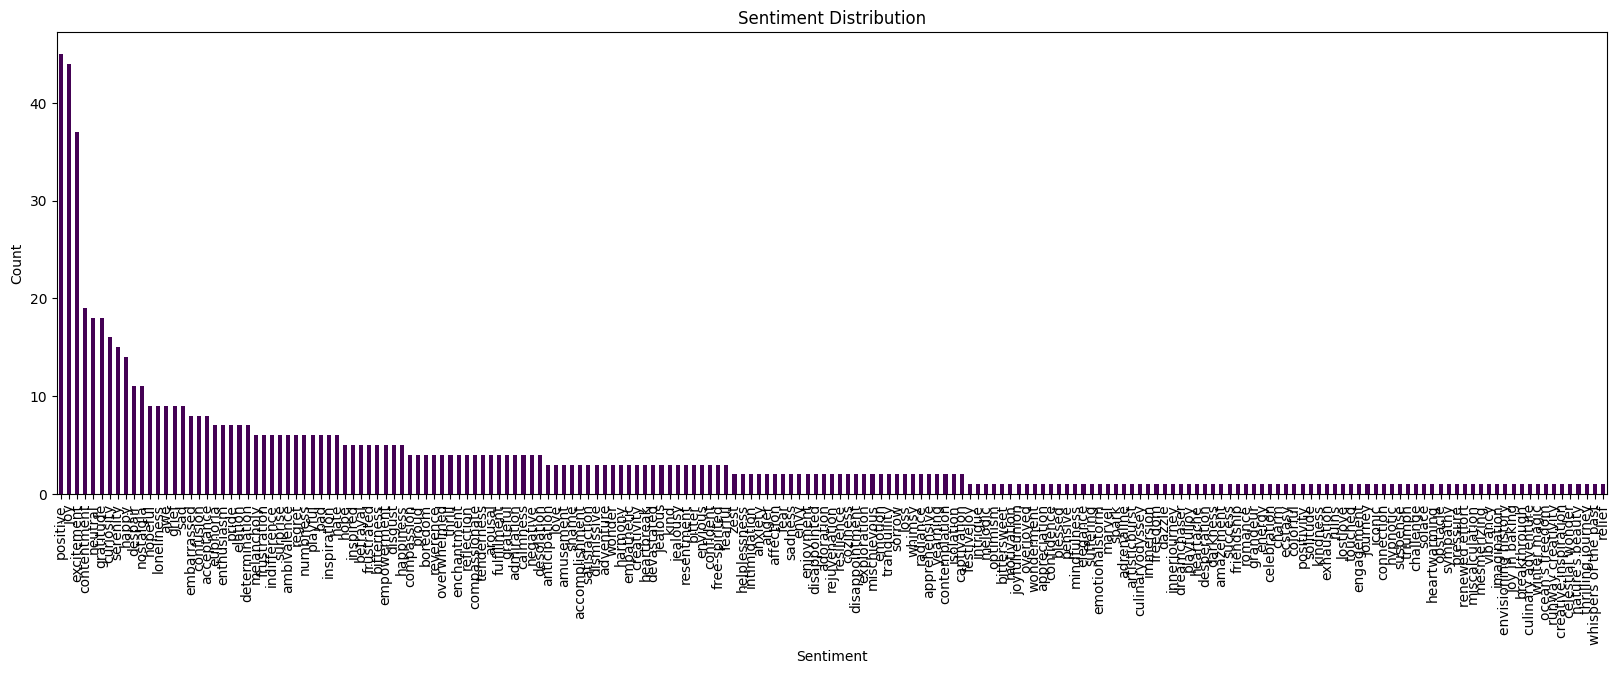

In [35]:
#sentiment distribution
plt.figure(figsize=(20,6))
df['Sentiment'].value_counts().plot(kind='bar', colormap = 'viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

##### -The most common sentiment in the dataset is 'Positive'.
    -This suggests that users in the dataset tend to share more optimistic and engaging experiences online.
    -Negative posts are present as well, but they appear less frequently compared to positive and neutral content.

### PLATFORM DISTRIBUTION

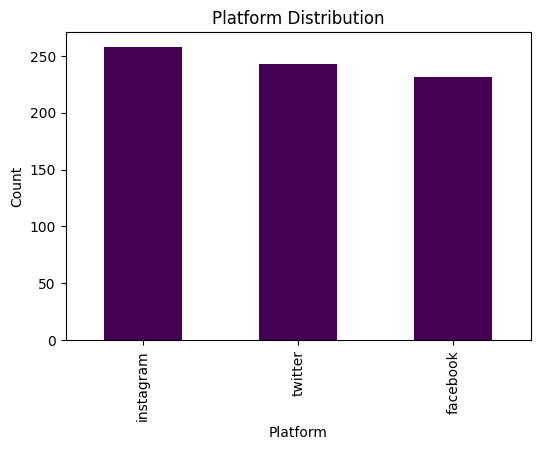

In [36]:
#platform distribution
plt.figure(figsize=(6,4))
df['Platform'].value_counts().plot(kind='bar', colormap = 'viridis')
plt.title('Platform Distribution')
plt.xlabel('Platform')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

##### - The platform with the highest activity is Instagram.
    -This indicates that users on this platform are more active in sharing opinions, reactions, and experiences.
    -Different platforms may also attract different emotional tones depending on their audience.

### ENGAGEMENT ANALYSIS

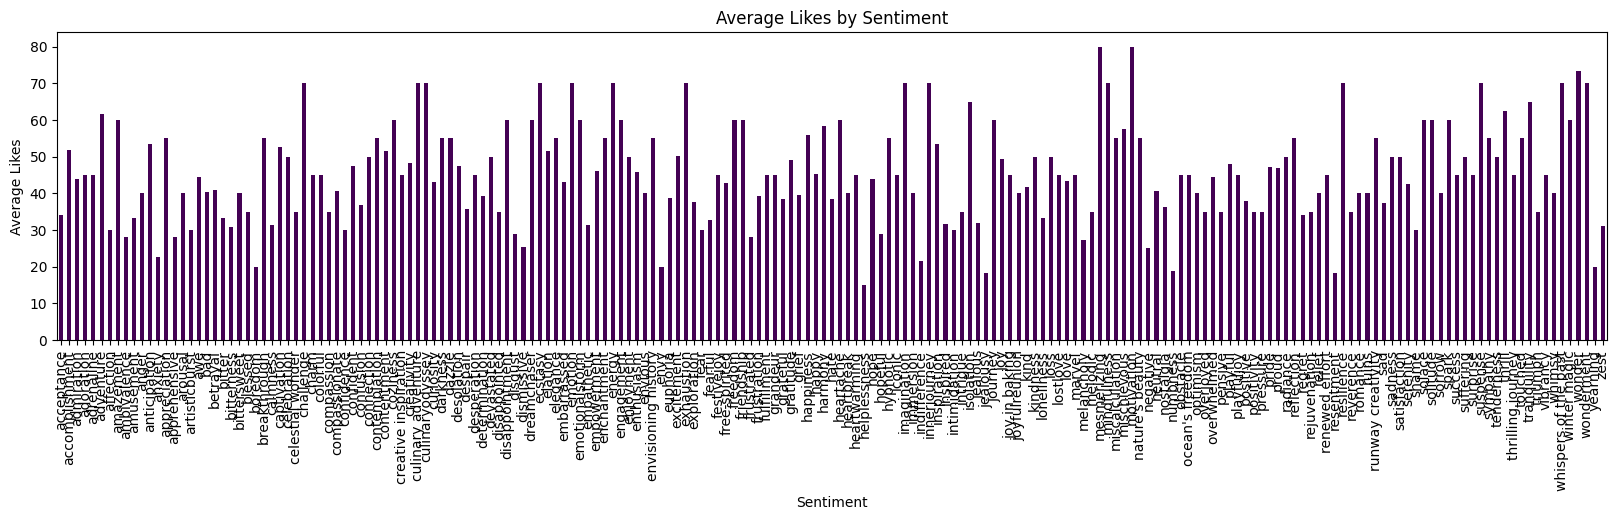

In [37]:
#average likes by sentiment
plt.figure(figsize=(20,4))
df.groupby('Sentiment')['Likes'].mean().plot(kind='bar', colormap = 'viridis')
plt.title('Average Likes by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Likes')
plt.xticks(rotation=90)
plt.show()

#### - Posts with 'Motivation' sentiment received the highest average engagement in terms of likes.
    -This may suggest that audiences interact more with emotionally uplifting or relatable content.

### TOP COUNTRIES

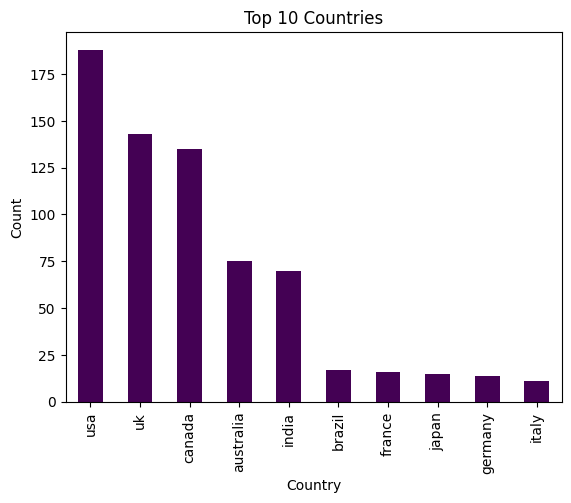

In [38]:
#top countries
df['Country'].value_counts().head(10).plot(kind='bar', colormap = 'viridis')
plt.title('Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

##### - The dataset includes posts from multiple countries, showing that sentiment analysis can reveal global social media behavior. Countries with higher posting activity may provide richer insights into online engagement and emotional expression.

### FINAL INTERPRETATION

##### - The dataset shows that positive sentiment dominates social media interactions.
        - Users generally engage more with positive and motivational posts, while neutral content remains common for everyday updates.
        - Negative sentiment exists but appears less dominant. The analysis also demonstrates how engagement metrics such as likes and retweets can be linked to emotional tone.
        - From a business perspective, companies and marketers can use sentiment analysis to better understand customer emotions, improve marketing campaigns, and monitor brand reputation in real time.